# Customer Segmentation using K-Means Clustering
This notebook performs RFM (Recency, Frequency, Monetary) analysis and K-Means clustering to segment customers.

Cluster Summary:
             recency  frequency     monetary
cluster                                    
0         78.451754  19.416667  5499.123026
1        520.109244   7.537815  1521.792605
2         84.778027  10.035874  1853.460987


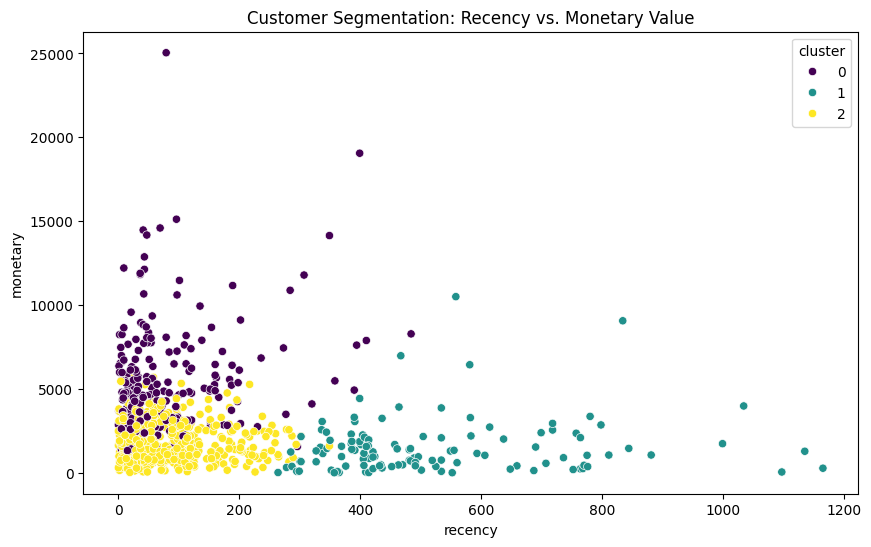

In [5]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to your local PostgreSQL database
# Credentials are loaded from the .env file in the project root
import os
from dotenv import load_dotenv
load_dotenv(os.path.join(os.path.dirname(os.getcwd()), '.env'))

db_user = os.getenv('POSTGRES_USER', 'postgres')
db_pass = os.getenv('POSTGRES_PASSWORD', 'password')
db_host = os.getenv('POSTGRES_HOST', 'localhost')
db_port = os.getenv('POSTGRES_PORT', '5432')
db_name = os.getenv('POSTGRES_DB', 'retail_dw')
engine = create_engine(f'postgresql://{db_user}:{db_pass}@{db_host}:{db_port}/{db_name}')

# 2. Extract Data (Calculate RFM Metrics)
query = """
    SELECT 
        c.customer_id,
        c.customer_name,
        MAX(d.date) AS last_purchase_date,
        COUNT(DISTINCT f.sale_id) AS frequency,
        SUM(f.revenue) AS monetary
    FROM fact_sales f
    JOIN dim_customer c ON f.customer_id = c.customer_id
    JOIN dim_date d ON f.date_id = d.date_id
    GROUP BY c.customer_id, c.customer_name
"""
df_rfm = pd.read_sql(query, engine)

# Convert last_purchase_date to Recency (days since last purchase)
# Note: In a real scenario, use today's date. For static data, use the max date in the dataset.
df_rfm['last_purchase_date'] = pd.to_datetime(df_rfm['last_purchase_date'])
max_date = df_rfm['last_purchase_date'].max()
df_rfm['recency'] = (max_date - df_rfm['last_purchase_date']).dt.days

# Drop the date column as we only need the numeric RFM columns
features = df_rfm[['recency', 'frequency', 'monetary']]

# 3. Scale the Data (Crucial for K-Means)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 4. Apply K-Means Clustering
# We will segment them into 3 tiers (e.g., High Value, Mid Value, Low Value)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_rfm['cluster'] = kmeans.fit_predict(scaled_features)

# 5. Analyze and Label the Segments
cluster_summary = df_rfm.groupby('cluster')[['recency', 'frequency', 'monetary']].mean()
print("Cluster Summary:\n", cluster_summary)

# 6. Visualize the Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_rfm, x='recency', y='monetary', hue='cluster', palette='viridis')
plt.title('Customer Segmentation: Recency vs. Monetary Value')
plt.show()

## Elbow Method — Optimal K Selection
Run K-Means for K=2 to 10 and plot inertia (WCSS) to find the optimal number of clusters.

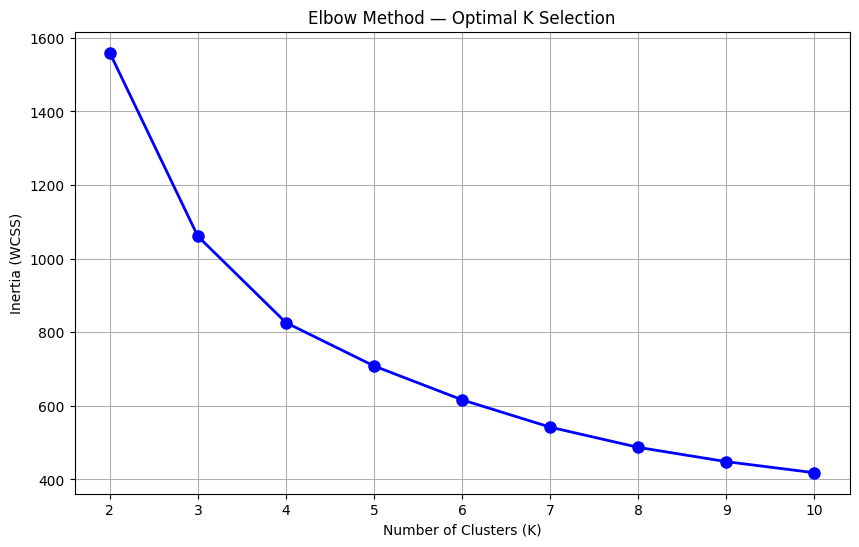

Inertia values for each K:
  K=2: 1559.50
  K=3: 1060.82
  K=4: 826.19
  K=5: 708.42
  K=6: 616.41
  K=7: 542.10
  K=8: 487.21
  K=9: 448.40
  K=10: 418.26


In [6]:
# === ELBOW METHOD: Finding Optimal K ===
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method \u2014 Optimal K Selection')
plt.grid(True)
plt.xticks(list(k_range))
plt.show()

print("Inertia values for each K:")
for k, inertia in zip(k_range, inertias):
    print(f"  K={k}: {inertia:.2f}")

## Silhouette Score Evaluation
Evaluate cluster quality using the Silhouette Score metric for different values of K.

In [7]:
from sklearn.metrics import silhouette_score

# === SILHOUETTE SCORE EVALUATION ===
sil_score = silhouette_score(scaled_features, df_rfm['cluster'])
print(f"Silhouette Score for K=3: {sil_score:.4f}")
print()
print("Interpretation:")
print("  - Score ranges from -1 to 1")
print("  - Values closer to 1 indicate well-separated, dense clusters")
print("  - Values near 0 indicate overlapping clusters")
print("  - Negative values indicate possible mis-assignment")

# Silhouette scores for different K values
print()
print("Silhouette Scores for K=2 to K=10:")
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)
    score = silhouette_score(scaled_features, labels)
    marker = " <-- current" if k == 3 else ""
    print(f"  K={k}: {score:.4f}{marker}")

Silhouette Score for K=3: 0.3920

Interpretation:
  - Score ranges from -1 to 1
  - Values closer to 1 indicate well-separated, dense clusters
  - Values near 0 indicate overlapping clusters
  - Negative values indicate possible mis-assignment

Silhouette Scores for K=2 to K=10:
  K=2: 0.3432
  K=3: 0.3920 <-- current
  K=4: 0.3613
  K=5: 0.3278
  K=6: 0.3272
  K=7: 0.3293
  K=8: 0.3046
  K=9: 0.3118
  K=10: 0.2860


## Cluster Labeling & Business Profiling
Assign meaningful business labels to each cluster and generate actionable recommendations.

CUSTOMER SEGMENTATION — BUSINESS PROFILE

--- High-Value (Cluster 0) ---
  Customers     : 228
  Avg Recency   : 78 days since last purchase
  Avg Frequency : 19.4 purchases
  Avg Monetary  : $5,499.12 total spend

--- Mid-Value (Cluster 2) ---
  Customers     : 446
  Avg Recency   : 85 days since last purchase
  Avg Frequency : 10.0 purchases
  Avg Monetary  : $1,853.46 total spend

--- Low-Value / At-Risk (Cluster 1) ---
  Customers     : 119
  Avg Recency   : 520 days since last purchase
  Avg Frequency : 7.5 purchases
  Avg Monetary  : $1,521.79 total spend

BUSINESS RECOMMENDATIONS

1. HIGH-VALUE Customers:
   - These are your best customers with high spend and frequent purchases.
   - Action: Implement loyalty/VIP programs, exclusive offers, and personalized
     communication to maintain engagement and prevent churn.

2. MID-VALUE Customers:
   - These customers have moderate engagement and spending.
   - Action: Run targeted promotions to increase purchase frequency.
     Consi

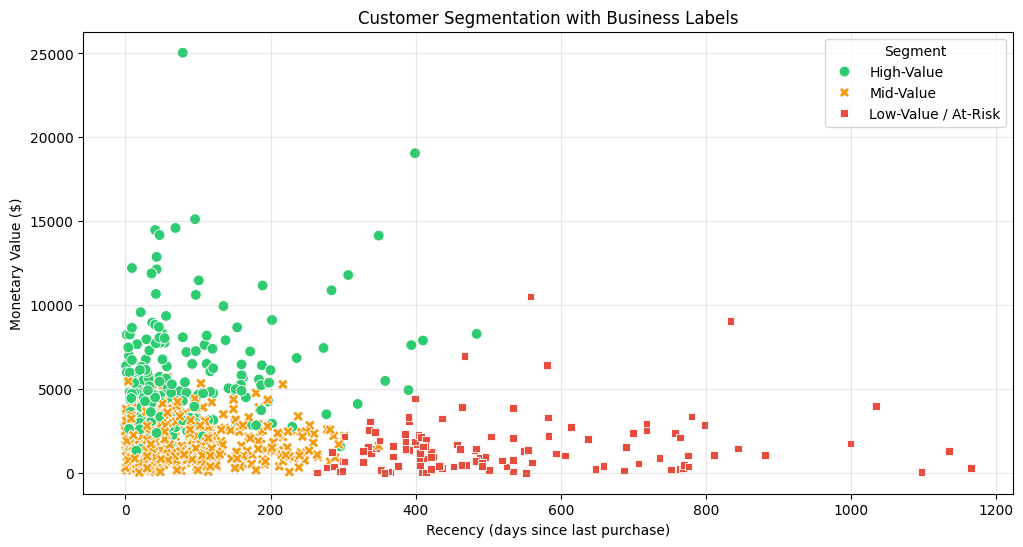

In [8]:
# === CLUSTER LABELING & BUSINESS PROFILING ===

# Sort clusters by monetary value to assign meaningful labels
cluster_order = cluster_summary.sort_values('monetary', ascending=False).index.tolist()

label_map = {}
label_names = ['High-Value', 'Mid-Value', 'Low-Value / At-Risk']
for i, cluster_id in enumerate(cluster_order):
    label_map[cluster_id] = label_names[i]

df_rfm['segment'] = df_rfm['cluster'].map(label_map)

# Print labeled cluster profile
print("=" * 70)
print("CUSTOMER SEGMENTATION \u2014 BUSINESS PROFILE")
print("=" * 70)

for cluster_id in cluster_order:
    label = label_map[cluster_id]
    subset = df_rfm[df_rfm['cluster'] == cluster_id]
    count = len(subset)
    avg_recency = subset['recency'].mean()
    avg_frequency = subset['frequency'].mean()
    avg_monetary = subset['monetary'].mean()
    
    print(f"\n--- {label} (Cluster {cluster_id}) ---")
    print(f"  Customers     : {count}")
    print(f"  Avg Recency   : {avg_recency:.0f} days since last purchase")
    print(f"  Avg Frequency : {avg_frequency:.1f} purchases")
    print(f"  Avg Monetary  : ${avg_monetary:,.2f} total spend")

print("\n" + "=" * 70)
print("BUSINESS RECOMMENDATIONS")
print("=" * 70)
print("""\n1. HIGH-VALUE Customers:
   - These are your best customers with high spend and frequent purchases.
   - Action: Implement loyalty/VIP programs, exclusive offers, and personalized
     communication to maintain engagement and prevent churn.

2. MID-VALUE Customers:
   - These customers have moderate engagement and spending.
   - Action: Run targeted promotions to increase purchase frequency.
     Consider upselling and cross-selling strategies.

3. LOW-VALUE / AT-RISK Customers:
   - These customers show low engagement, infrequent purchases, or declining spend.
   - Action: Re-engagement campaigns (discounts, reminders), feedback surveys
     to identify pain points, and special win-back offers.""")

# Visualize labeled segments
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_rfm, x='recency', y='monetary', hue='segment',
                palette={'High-Value': '#2ecc71', 'Mid-Value': '#f39c12', 'Low-Value / At-Risk': '#e74c3c'},
                style='segment', s=60)
plt.title('Customer Segmentation with Business Labels')
plt.xlabel('Recency (days since last purchase)')
plt.ylabel('Monetary Value ($)')
plt.legend(title='Segment')
plt.grid(True, alpha=0.3)
plt.show()